<font color="#CA0032"><h1 align="left">**Redes recurrentes profundas**</h1></font>

<font color="#6E6E6E"><h1 align="left">**Predicción de series temporales**</h1></font>

<h2 align="left">Manuel Sánchez-Montañés</h2>

<font color="#6E6E6E"><h2 align="left">manuel.smontanes@gmail.com</h2></font>

**Notebook: Manuel Sánchez-Montañés**

**Datos: Carlos Rosado**

### **Usaremos un esquema many to one:**

<img src="https://drive.google.com/uc?export=download&id=1iokh576AiK2iFhftPogSBsNXixAi-LBg" align="center" style="float" width="500">

In [1]:
COLAB = True

## <font color="#CA3532"> **Importar librerías**

In [2]:
import numpy as np
import pandas as pd

from keras.models import Sequential, load_model
from keras.layers import Dense, LSTM, GRU
from keras.callbacks import ModelCheckpoint

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score as R2_score

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [3]:
def download_file_from_google_drive(file_id, dest_file, unzip=False):
  aux = "'https://drive.usercontent.google.com/download?id={}&export=download&confirm=t&uuid=9699f0e2-e760-49fc-b12e-49f140095280'".format(file_id)
  !wget $aux -O $dest_file
  if unzip:
    !unzip -qq -o $dest_file
    !rm $dest_file

## <font color="#CA3532"> **Carga de datos**

In [4]:
if COLAB:
    download_file_from_google_drive(file_id='12QZpA_L1JncFIVEryee0aeL66Ep3xpOy', dest_file='./datos_pasajeros.csv')

data = pd.read_csv('datos_pasajeros.csv')
data.head(20)

--2026-05-28 10:41:12--  https://drive.usercontent.google.com/download?id=12QZpA_L1JncFIVEryee0aeL66Ep3xpOy&export=download&confirm=t&uuid=9699f0e2-e760-49fc-b12e-49f140095280
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.134.132, 2607:f8b0:400c:c05::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.134.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19189 (19K) [application/octet-stream]
Saving to: ‘./datos_pasajeros.csv’

./datos_pasajeros.c 100%[===================>]  18.74K  --.-KB/s    in 0s      

2026-05-28 10:41:13 (68.4 MB/s) - ‘./datos_pasajeros.csv’ saved [19189/19189]



,fecha,mes,festivo,npasajeros,semana_mes,day_of_week
0,2015-01-01,1,1,1125,0,3
1,2015-01-02,1,0,3592,0,4
2,2015-01-03,1,0,3001,0,5
3,2015-01-04,1,0,2260,0,6
4,2015-01-05,1,0,2767,0,0
5,2015-01-06,1,1,1342,0,1
6,2015-01-07,1,0,3867,0,2
7,2015-01-08,1,0,3904,1,3
8,2015-01-09,1,0,3678,1,4
9,2015-01-10,1,0,2631,1,5


## <font color="#CA3532"> **Librerías y funciones adicionales**

In [5]:
if COLAB:
    download_file_from_google_drive(file_id='1LYuVxpFdsoxgl89tku6BtEH3HuYcGd2g',
                                    dest_file='./my_utils_series_temporales.py.zip', unzip=True)

--2026-05-28 10:41:13--  https://drive.usercontent.google.com/download?id=1LYuVxpFdsoxgl89tku6BtEH3HuYcGd2g&export=download&confirm=t&uuid=9699f0e2-e760-49fc-b12e-49f140095280
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.134.132, 2607:f8b0:400c:c05::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.134.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2010 (2.0K) [application/octet-stream]
Saving to: ‘./my_utils_series_temporales.py.zip’

./my_utils_series_t 100%[===================>]   1.96K  --.-KB/s    in 0s      

2026-05-28 10:41:14 (23.0 MB/s) - ‘./my_utils_series_temporales.py.zip’ saved [2010/2010]



In [6]:
from my_utils_series_temporales import int2dummy, enventanar, info_enventanado, NAN

In [7]:
def grafica_entrenamiento(tr_mse, val_mse):
    ax=plt.figure(figsize=(10,4)).gca()
    plt.plot(1+np.arange(len(tr_mse)), tr_mse)
    plt.plot(1+np.arange(len(val_mse)), val_mse)
    plt.title('mse del modelo', fontsize=18)
    plt.xlabel('epoca', fontsize=18)
    plt.ylabel('mse', fontsize=18)
    plt.legend(['entrenamiento', 'validación'], loc='upper left')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()

## <font color="#CA3532"> **Desarrollo y validación del modelo**

In [8]:
data.shape

(790, 6)

In [9]:
data.dtypes

,0
fecha,object
mes,int64
festivo,int64
npasajeros,int64
semana_mes,int64
day_of_week,int64


In [10]:
data["fecha"][0]

'2015-01-01'

In [11]:
data.set_index("fecha", inplace=True)

In [12]:
data.head()

,mes,festivo,npasajeros,semana_mes,day_of_week
fecha,,,,,
2015-01-01,1,1,1125,0,3
2015-01-02,1,0,3592,0,4
2015-01-03,1,0,3001,0,5
2015-01-04,1,0,2260,0,6
2015-01-05,1,0,2767,0,0


In [13]:
fechas      = data.index.values
target      = data["npasajeros"].values
festivo     = data["festivo"].values
mes         = data["mes"].values
semana_mes  = data["semana_mes"].values
day_of_week = data["day_of_week"].values

In [14]:
data.describe()

,mes,festivo,npasajeros,semana_mes,day_of_week
count,790.000000,790.000000,790.000000,790.000000,790.000000
mean,6.143038,0.036709,3065.578481,1.078481,3.001266
std,3.578353,0.188165,996.916455,0.730587,2.002216
min,1.000000,0.000000,574.000000,0.000000,0.000000
25%,3.000000,0.000000,2143.750000,1.000000,1.000000
50%,6.000000,0.000000,3429.500000,1.000000,3.000000
75%,9.000000,0.000000,3917.750000,2.000000,5.000000
max,12.000000,1.000000,6465.000000,2.000000,6.000000


In [15]:
mes = mes - 1 # para que empiece en 0 (luego asociaremos un embedding a mes, y el código de mes tiene que empezar en 0)

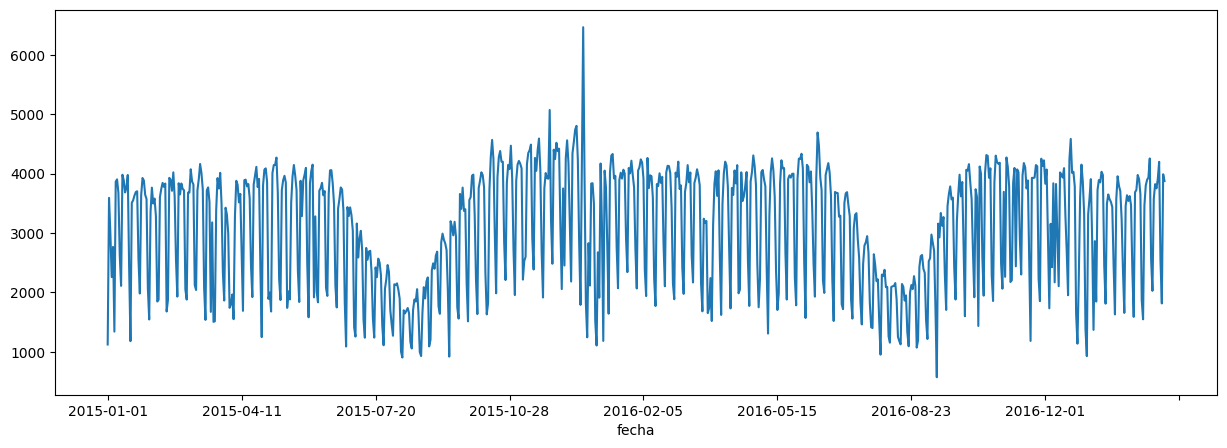

In [16]:
data["npasajeros"].plot(figsize=(15,5));

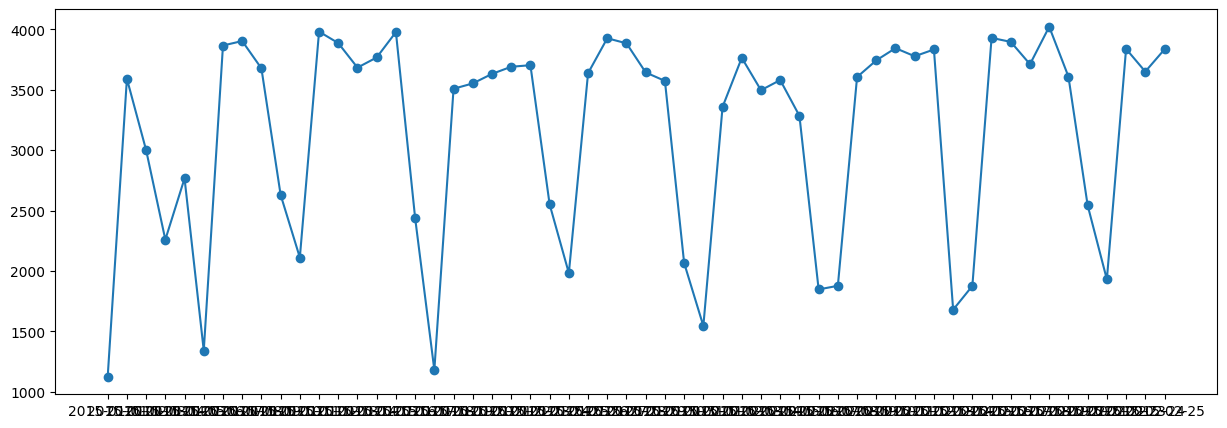

In [17]:
plt.figure(figsize=(15,5))
plt.plot(data["npasajeros"][:56], "-o");

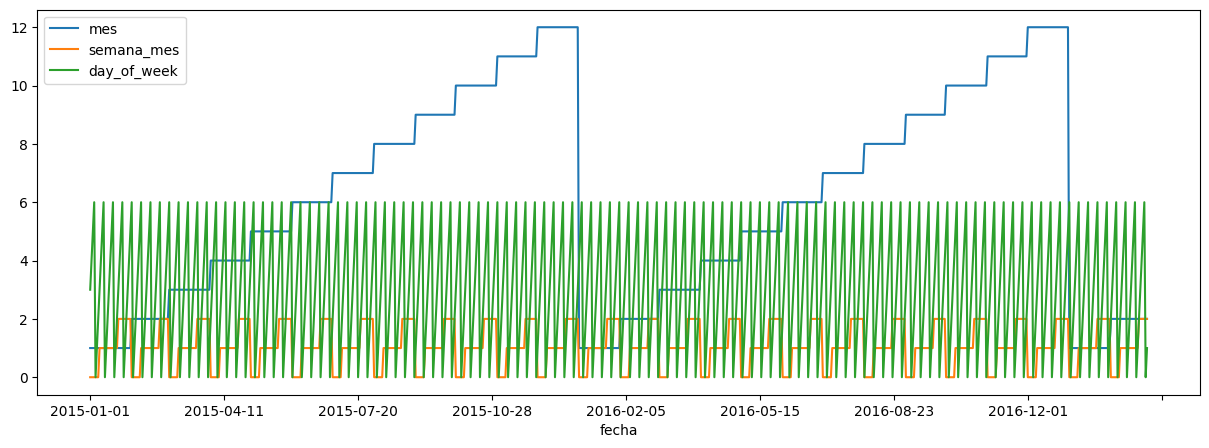

In [18]:
data[["mes", "semana_mes", "day_of_week"]].plot(figsize=(15,5));

In [19]:
fecha_corte = data.index[int(0.8*len(data))]
fecha_corte

'2016-09-24'

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(data[["npasajeros"]][:fecha_corte])

StandardScaler()

In [21]:
target_transf = scaler.transform(data[["npasajeros"]])[:,0]
target_transf[:5]

array([-1.8699818 ,  0.57226043, -0.01280854, -0.74637218, -0.24446022])

In [22]:
# prueba enventanado

# series univariables a enventanar:
series = [target_transf, festivo, day_of_week]
se_saben_antes = [False, True, False]
nombres_series = ["target_transf", "festivo", "day_of_week"]

data_window = 5 # lookback (tamaño de la ventana)

X, y = enventanar(series,
                  target=0, # cuál es la variable endógena a predecir
                  se_saben_antes=se_saben_antes, # si adelanto o no 1 día la información
                  W_in=data_window)

In [23]:
X.shape

(790, 5, 3)

In [24]:
y.shape

(790,)

In [25]:
X[5]

array([[-1.8699818 ,  0.        ,  3.        ],
       [ 0.57226043,  0.        ,  4.        ],
       [-0.01280854,  0.        ,  5.        ],
       [-0.74637218,  0.        ,  6.        ],
       [-0.24446022,  1.        ,  0.        ]])

In [26]:
info_enventanado(X[:10], y[:10], nombres_series,
                 nombre_target="target_transf", tiempos=fechas)

10 ventanas creadas

X.shape=(10, 5, 3)  Y.shape=(10,) 

 Ventana 0: 


X[0].shape=(5, 3) 
 
 
   
 ?0 
 ?1 
 ?2 
 ?3 
 ?4 
 
 
 
 
 target_transf 
 nan 
 nan 
 nan 
 nan 
 nan 
 
 
 festivo 
 nan 
 nan 
 nan 
 nan 
 1.000000 
 
 
 day_of_week 
 nan 
 nan 
 nan 
 nan 
 nan 
 
 
 
__
 
 Y[0]=-1.8699818007007307 
 
 
   
 2015-01-01 
 
 
 
 
 target_transf 
 -1.869982

 Ventana 1: 


X[1].shape=(5, 3) 
 
 
   
 ?0 
 ?1 
 ?2 
 ?3 
 2015-01-01 
 
 
 
 
 target_transf 
 nan 
 nan 
 nan 
 nan 
 -1.869982 
 
 
 festivo 
 nan 
 nan 
 nan 
 1.000000 
 0.000000 
 
 
 day_of_week 
 nan 
 nan 
 nan 
 nan 
 3.000000 
 
 
 
__
 
 Y[1]=0.5722604291717529 
 
 
   
 2015-01-02 
 
 
 
 
 target_transf 
 0.572260

 Ventana 2: 


...

X[7].shape=(5, 3) 
 
 
   
 2015-01-03 
 2015-01-04 
 2015-01-05 
 2015-01-06 
 2015-01-07 
 
 
 
 
 target_transf 
 -0.012809 
 -0.746372 
 -0.244460 
 -1.655160 
 0.844501 
 
 
 festivo 
 0.000000 
 0.000000 
 1.000000 
 0.000000 
 0.000000 
 
 
 day_of_week 
 5.000000 
 6.000000 
 0.000000 
 1.000000 
 2.000000 
 
 
 
__
 
 Y[7]=0.8811293289367367 
 
 
   
 2015-01-08 
 
 
 
 
 target_transf 
 0.881129

 Ventana 8: 


X[8].shape=(5, 3) 
 
 
   
 2015-01-04 
 2015-01-05 
 2015-01-06 
 2015-01-07 
 2015-01-08 
 
 
 
 
 target_transf 
 -0.746372 
 -0.244460 
 -1.655160 
 0.844501 
 0.881129 
 
 
 festivo 
 0.000000 
 1.000000 
 0.000000 
 0.000000 
 0.000000 
 
 
 day_of_week 
 6.000000 
 0.000000 
 1.000000 
 2.000000 
 3.000000 
 
 
 
__
 
 Y[8]=0.6573973694915882 
 
 
   
 2015-01-09 
 
 
 
 
 target_transf 
 0.657397

 Ventana 9: 


X[9].shape=(5, 3) 
 
 
   
 2015-01-05 
 2015-01-06 
 2015-01-07 
 2015-01-08 
 2015-01-09 
 
 
 
 
 target_transf 
 -0.244460 
 -1.655160 
 0.844501 
 0.881129 
 0.657397 
 
 
 festivo 
 1.000000 
 0.000000 
 0.000000 
 0.000000 
 0.000000 
 
 
 day_of_week 
 0.000000 
 1.000000 
 2.000000 
 3.000000 
 4.000000 
 
 
 
__
 
 Y[9]=-0.37909538068128995 
 
 
   
 2015-01-10 
 
 
 
 
 target_transf 
 -0.379095

In [27]:
# Lo anterior era una prueba. Ahora voy a enventanar cada
# variable por separado, porque las voy a tratar por separado
# en mi red

series0         = [target_transf]
se_saben_antes0 = [False]
nombres_series0 = ["target_transf"]

X0, y = enventanar(series0,
                  target=0, # cuál es la variable endógena a predecir
                  se_saben_antes=se_saben_antes0,
                  W_in=data_window)


series1         = [festivo]
se_saben_antes1 = [True]
nombres_series1 = ["festivo"]

X1, _ = enventanar(series1,
                  target=0, # cuál es la variable endógena a predecir
                  se_saben_antes=se_saben_antes1,
                  W_in=data_window)

series2         = [mes]
se_saben_antes2 = [True]
nombres_series2 = ["mes"]

X2, _ = enventanar(series2,
                  target=0, # cuál es la variable endógena a predecir
                  se_saben_antes=se_saben_antes2,
                  W_in=data_window)

series3         = [semana_mes]
se_saben_antes3 = [True]
nombres_series3 = ["semana_mes"]

X3, _ = enventanar(series3,
                  target=0, # cuál es la variable endógena a predecir
                  se_saben_antes=se_saben_antes3,
                  W_in=data_window)

series4         = [day_of_week]
se_saben_antes4 = [True]
nombres_series4 = ["day_of_week"]

X4, _ = enventanar(series4,
                  target=0, # cuál es la variable endógena a predecir
                  se_saben_antes=se_saben_antes4,
                  W_in=data_window)

In [28]:
X0.shape, X1.shape, X2.shape, X3.shape, X4.shape

((790, 5, 1), (790, 5, 1), (790, 5, 1), (790, 5, 1), (790, 5, 1))

In [29]:
# posición de le fecha de corte dentro de data:
fcorte_pos = data.index.to_list().index(fecha_corte)
fcorte_pos

632

In [30]:
target_train = target[data_window:fcorte_pos] # número de pasajeros
y_train      = y[data_window:fcorte_pos] # número de pasajeros estandarizados
fechas_train = fechas[data_window:fcorte_pos]

X0_train = X0[data_window:fcorte_pos]
X1_train = X1[data_window:fcorte_pos]
X2_train = X2[data_window:fcorte_pos]
X3_train = X3[data_window:fcorte_pos]
X4_train = X4[data_window:fcorte_pos]

In [31]:
target_test = target[fcorte_pos:] # número de pasajeros
y_test      = y[fcorte_pos:] # número de pasajeros estandarizados
fechas_test = fechas[fcorte_pos:]

X0_test = X0[fcorte_pos:]
X1_test = X1[fcorte_pos:]
X2_test = X2[fcorte_pos:]
X3_test = X3[fcorte_pos:]
X4_test = X4[fcorte_pos:]

In [32]:
X0_train.shape, X1_train.shape, X2_train.shape, X3_train.shape, X4_train.shape

((627, 5, 1), (627, 5, 1), (627, 5, 1), (627, 5, 1), (627, 5, 1))

In [33]:
X0_test.shape, X1_test.shape, X2_test.shape, X3_test.shape, X4_test.shape

((158, 5, 1), (158, 5, 1), (158, 5, 1), (158, 5, 1), (158, 5, 1))

In [34]:
627+158+5

790

In [35]:
fecha_corte

'2016-09-24'

In [36]:
# Modelo

from keras.layers import Input, Embedding, concatenate
from keras import Model, optimizers # modo funcional

In [37]:
dim_embedding = 2

input0 = Input(shape=(data_window, 1), name="endogena")
input1 = Input(shape=(data_window, 1), name="festivo")
input2 = Input(shape=(data_window,), name="mes") # mes es una categórica (índice)
input3 = Input(shape=(data_window,), name="semana_mes") # es una categórica (índice)
input4 = Input(shape=(data_window,), name="day_of_week") # es una categórica (índice)

embedding2 = Embedding(input_dim=12, # número de categorías
                       output_dim=dim_embedding,
                       input_length=data_window,
                       name="embedding_mes")(input2)

embedding3 = Embedding(input_dim=3, # número de categorías
                       output_dim=dim_embedding,
                       input_length=data_window,
                       name="embedding_semana_mes")(input3)

embedding4 = Embedding(input_dim=7, # número de categorías
                       output_dim=dim_embedding,
                       input_length=data_window,
                       name="embedding_day_of_week")(input4)

x = concatenate([input0, input1, embedding2, embedding3, embedding4])
x2 = LSTM(units=2)(x)
x3 = Dense(units=1)(x2)

model = Model(inputs=[input0, input1, input2, input3, input4],
              outputs=x3)
model.compile(loss="mean_squared_error", optimizer=optimizers.RMSprop())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [38]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mes (InputLayer)    │ (None, 5)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ semana_mes          │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ day_of_week         │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ endogena            │ (None, 5, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ festivo             │ (None, 5, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_mes       │ (None, 5, 2)      │         24 │ mes[0][0]         │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_semana_m… │ (None, 5, 2)      │          6 │ semana_mes[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_day_of_w… │ (None, 5, 2)      │         14 │ day_of_week[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 5, 8)      │          0 │ endogena[0][0],   │
│ (Concatenate)       │                   │            │ festivo[0][0],    │
│                     │                   │            │ embedding_mes[0]… │
│                     │                   │            │ embedding_semana… │
│                     │                   │            │ embedding_day_of… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 2)         │         88 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │          3 │ lstm[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 135 (540.00 B)

 Trainable params: 135 (540.00 B)

 Non-trainable params: 0 (0.00 B)

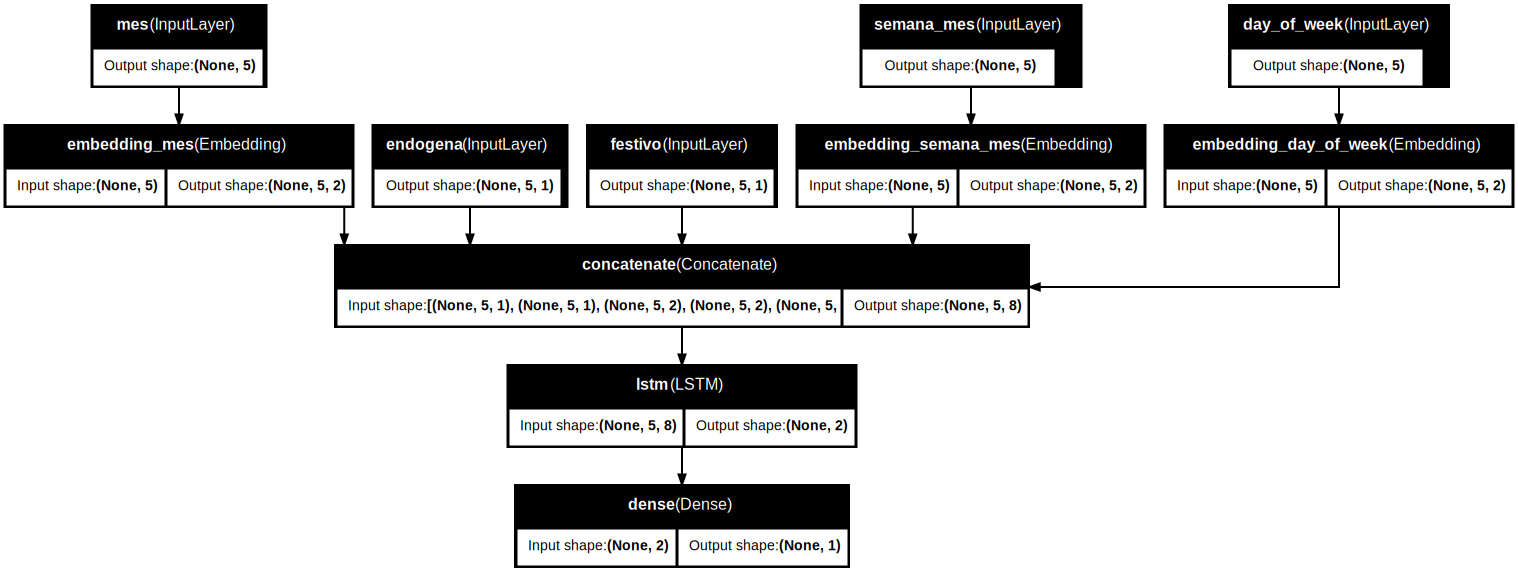

In [39]:
from IPython.display import SVG
from keras.utils import model_to_dot

if COLAB:
  display(SVG(model_to_dot(model, show_shapes=True, dpi=72).create(prog="dot",
                                                                   format="svg")))
else:
  display(SVG(model_to_dot(model, show_shapes=True).create(prog="dot",
                                                           format="svg")))

In [40]:
epochs = 2000
batch_size = 32
Nval = 200 # los 200 últimos días de training los voy a usar como validación

X0_tr = X0_train[:-Nval]
X1_tr = X1_train[:-Nval]
X2_tr = X2_train[:-Nval]
X3_tr = X3_train[:-Nval]
X4_tr = X4_train[:-Nval]
y_tr  = y_train[:-Nval]

X0_va = X0_train[-Nval:]
X1_va = X1_train[-Nval:]
X2_va = X2_train[-Nval:]
X3_va = X3_train[-Nval:]
X4_va = X4_train[-Nval:]
y_va  = y_train[-Nval:]

In [41]:
tr_loss_history = []
va_loss_history = []

modelpath = "best_model.h5" # fichero en el que guardaré el mejor modelo
checkpoint = ModelCheckpoint(modelpath, monitor="val_loss", verbose=2, save_best_only=True)

Xs_tr = {
    "endogena": X0_tr,
    "festivo": X1_tr,
    "mes": X2_tr,
    "semana_mes": X3_tr,
    "day_of_week": X4_tr,
}

Xs_va = {
    "endogena": X0_va,
    "festivo": X1_va,
    "mes": X2_va,
    "semana_mes": X3_va,
    "day_of_week": X4_va,
}

Xs_test = {
    "endogena": X0_test,
    "festivo": X1_test,
    "mes": X2_test,
    "semana_mes": X3_test,
    "day_of_week": X4_test,
}


Epoch 1: val_loss improved from None to 1.11634, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5


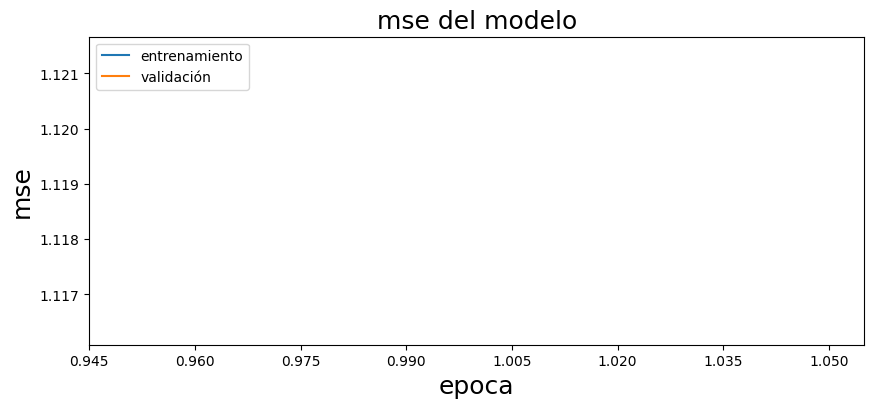


Epoch 1: val_loss improved from 1.11634 to 1.08864, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss improved from 1.08864 to 1.06150, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss improved from 1.06150 to 1.02849, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss improved from 1.02849 to 1.00098, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss improved from 1.00098 to 0.96440, saving model to best_model.h5


...


Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss improved from 0.16710 to 0.16072, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss improved from 0.16072 to 0.15340, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss improved from 0.15340 to 0.15095, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss improved from 0.15095 to 0.14904, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5


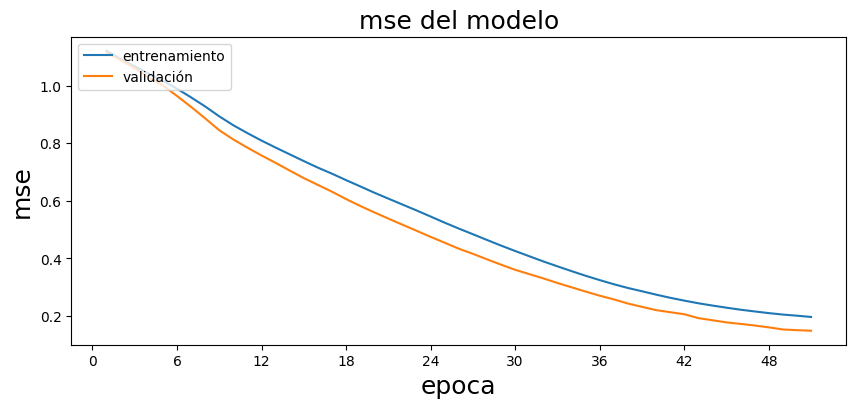


Epoch 1: val_loss improved from 0.14904 to 0.14332, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss improved from 0.14332 to 0.14197, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss improved from 0.14197 to 0.13644, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss improved from 0.13644 to 0.13485, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss improved from 0.13485 to 0.13285, saving model to best_model.h5


...


Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.09358

Epoch 1: val_loss did not improve from 0.09358

Epoch 1: val_loss did not improve from 0.09358

Epoch 1: val_loss did not improve from 0.09358

Epoch 1: val_loss did not improve from 0.09358

Epoch 1: val_loss improved from 0.09358 to 0.09267, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.09267

Epoch 1: val_loss did not improve from 0.09267

Epoch 1: val_loss did not improve from 0.09267

Epoch 1: val_loss improved from 0.09267 to 0.09249, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.09249

Epoch 1: val_loss improved from 0.09249 to 0.09092, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.09092

Epoch 1: val_loss improved from 0.09092 to 0.08898, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.08898


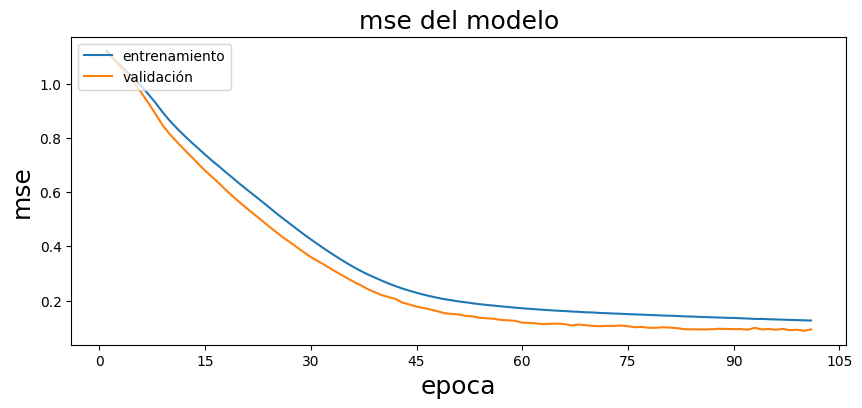


Epoch 1: val_loss improved from 0.08898 to 0.08747, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.08747

Epoch 1: val_loss improved from 0.08747 to 0.08676, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.08676

Epoch 1: val_loss improved from 0.08676 to 0.08562, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.08562

Epoch 1: val_loss did not improve from 0.08562

Epoch 1: val_loss improved from 0.08562 to 0.08386, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.08386

Epoch 1: val_loss did not improve from 0.08386

Epoch 1: val_loss improved from 0.08386 to 0.08357, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from 0.08357

Epoch 1: val_loss did not improve from


Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.08313

Epoch 1: val_loss did not improve from 0.08313

Epoch 1: val_loss did not improve from 0.08313

Epoch 1: val_loss did not improve from 0.08313

Epoch 1: val_loss did not improve from 0.08313

Epoch 1: val_loss did not improve from 0.08313

Epoch 1: val_loss did not improve from 0.08313

Epoch 1: val_loss did not improve from 0.08313

Epoch 1: val_loss did not improve from 0.08313

Epoch 1: val_loss improved from 0.08313 to 0.08203, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.08203


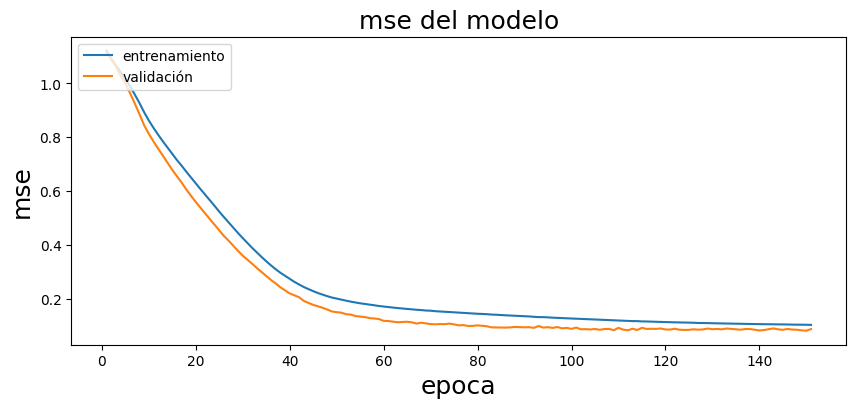


Epoch 1: val_loss improved from 0.08203 to 0.08119, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.08119

Epoch 1: val_loss did not improve from 0.08119

Epoch 1: val_loss did not improve from 0.08119

Epoch 1: val_loss did not improve from 0.08119

Epoch 1: val_loss did not improve from 0.08119

Epoch 1: val_loss did not improve from 0.08119

Epoch 1: val_loss improved from 0.08119 to 0.08089, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.08089

Epoch 1: val_loss did not improve from 0.08089

Epoch 1: val_loss did not improve from 0.08089

Epoch 1: val_loss did not improve from 0.08089

Epoch 1: val_loss improved from 0.08089 to 0.07887, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss did not improve from 0.07887

Epoch 1: val_loss improved from 0.07887 to 0.07693, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.07693

Epoch 1: val_loss did not improve from 0.07693

Epoch 1: val_loss did not improve from 0.07693

Epoch 1: val_loss did not improve from 0.07693

Epoch 1: val_loss did not improve from 0.07693

Epoch 1: val_loss did not improve from 0.07693

Epoch 1: val_loss did not improve from 0.07693

Epoch 1: val_loss did not improve from 0.07693

Epoch 1: val_loss improved from 0.07693 to 0.07267, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267


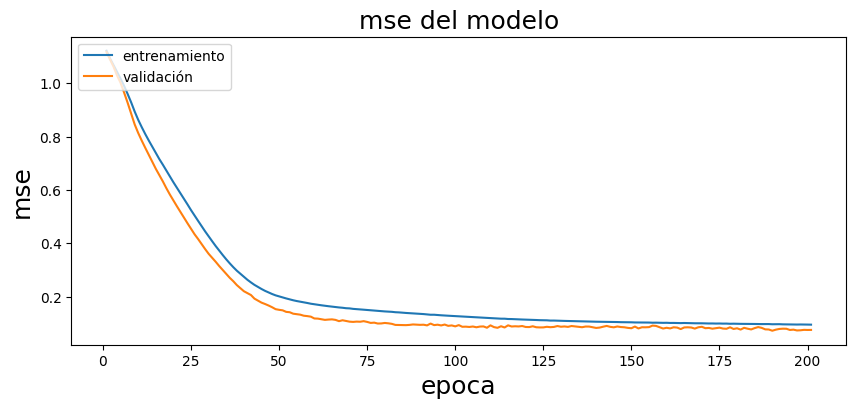


Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss did not improve from 0.07267

Epoch 1: val_loss improved from 0.07267 to 0.07174, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.07174

Epoch 1: val_loss improved from 0.07174 to 0.07071, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.07071

Epoch 1: val_loss did not improve from 0.07071

Epoch 1: val_loss improved from 0.07071 to 0.06944, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.06944

Epoch 1: val_loss did not improve from 0.06944

Epoch 1: val_loss did not improve from 0.06944

Epoch 1: val_loss improved from 0.06944 to 0.06787, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.06787

Epoch 1: val_loss did not improve from 0.06787

Epoch 1: val_loss did not improve from 0.06787

Epoch 1: val_loss did not improve from 0.06787

Epoch 1: val_loss did not improve from 0.06787

Epoch 1: val_loss did not improve from 0.06787

Epoch 1: val_loss did not improve from 0.06787

Epoch 1: val_loss did not improve from 0.06787

Epoch 1: val_loss improved from 0.06787 to 0.06505, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss did not improve from 0.06505

Epoch 1: val_loss improved from 0.06505 to 0.06430, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.06430

Epoch 1: val_loss did not improve from 0.06430

Epoch 1: val_loss did not improve from 0.06430

Epoch 1: val_loss did not improve from 0.06430


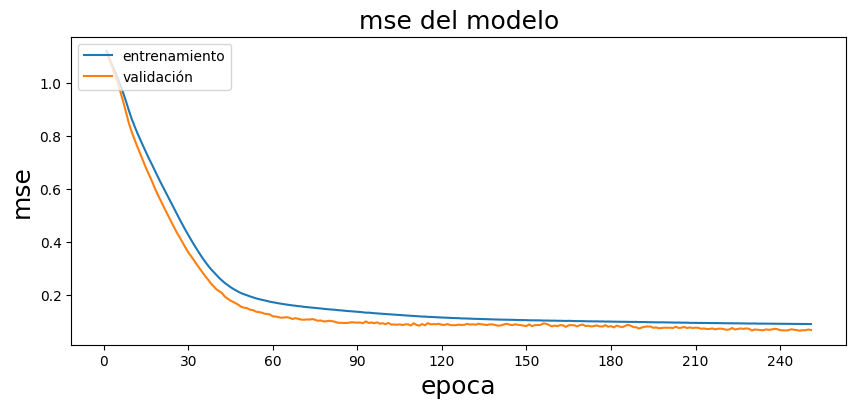


Epoch 1: val_loss did not improve from 0.06430

Epoch 1: val_loss did not improve from 0.06430

Epoch 1: val_loss did not improve from 0.06430

Epoch 1: val_loss did not improve from 0.06430

Epoch 1: val_loss improved from 0.06430 to 0.06269, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.06269

Epoch 1: val_loss did not improve from 0.06269

Epoch 1: val_loss did not improve from 0.06269

Epoch 1: val_loss did not improve from 0.06269

Epoch 1: val_loss did not improve from 0.06269

Epoch 1: val_loss did not improve from 0.06269

Epoch 1: val_loss did not improve from 0.06269

Epoch 1: val_loss did not improve from 0.06269

Epoch 1: val_loss did not improve from 0.06269

Epoch 1: val_loss improved from 0.06269 to 0.06185, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.06185

Epoch 1: val_loss did not improve from 0.06185

Epoch 1: val_loss improved from 0.06185 to 0.05979, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from 0.05979

Epoch 1: val_loss did not improve from


Epoch 1: finished saving model to best_model.h5


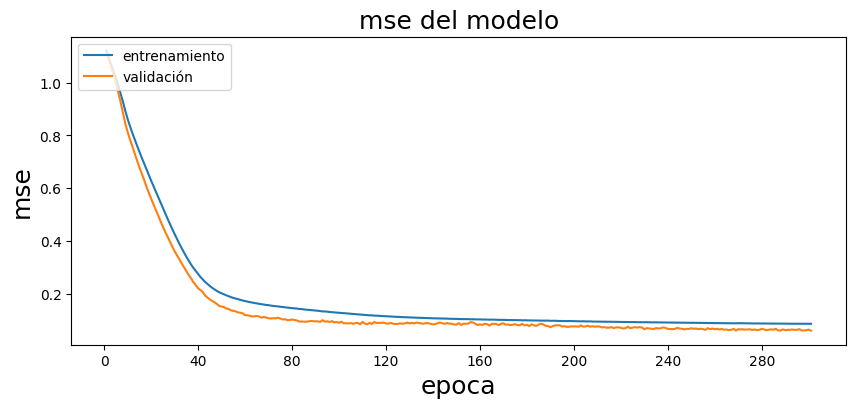


Epoch 1: val_loss did not improve from 0.05934

Epoch 1: val_loss did not improve from 0.05934

Epoch 1: val_loss did not improve from 0.05934

Epoch 1: val_loss did not improve from 0.05934

Epoch 1: val_loss did not improve from 0.05934

Epoch 1: val_loss did not improve from 0.05934

Epoch 1: val_loss improved from 0.05934 to 0.05771, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from 0.05771

Epoch 1: val_loss did not improve from


Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.05737

Epoch 1: val_loss did not improve from 0.05737

Epoch 1: val_loss improved from 0.05737 to 0.05661, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661


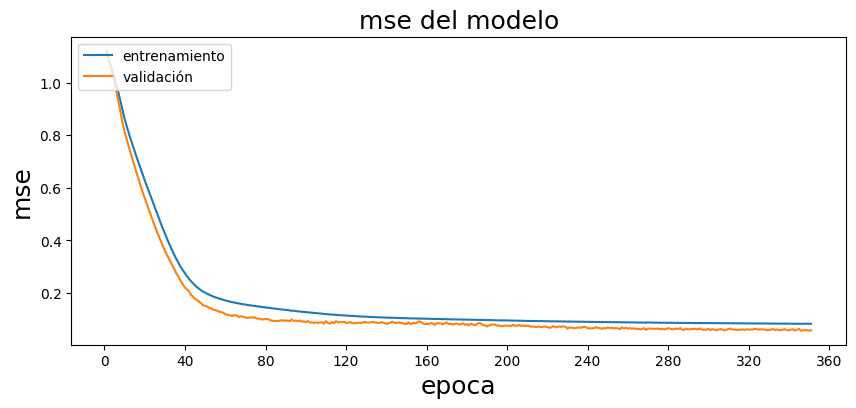


Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 0.05661

Epoch 1: val_loss did not improve from 


Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from 0.05647

Epoch 1: val_loss did not improve from


Epoch 1: finished saving model to best_model.h5

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522


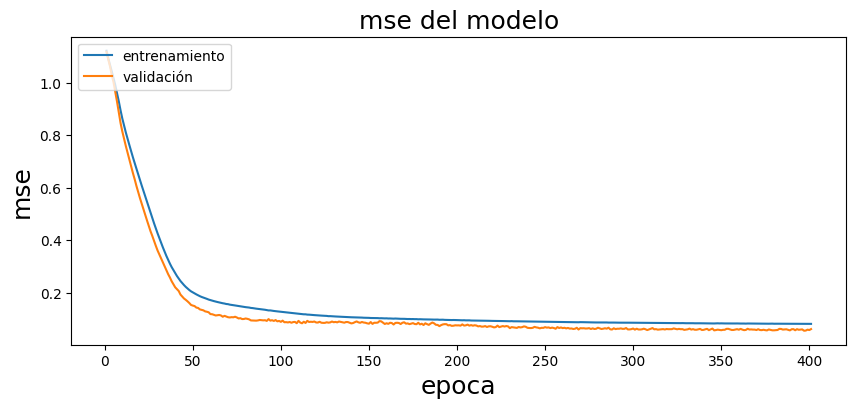


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

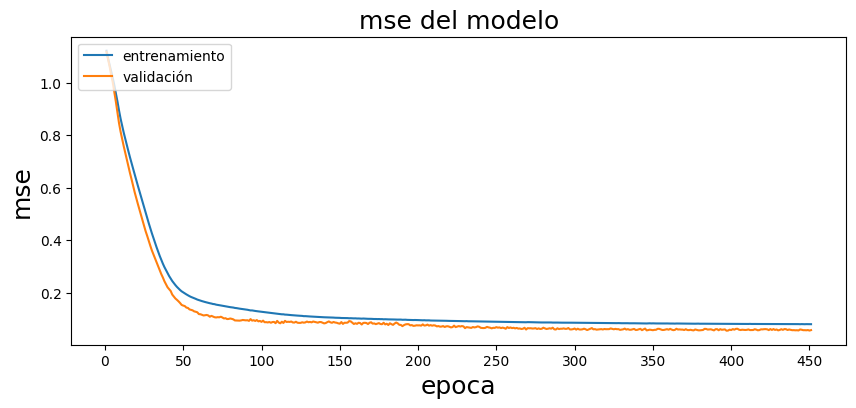


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

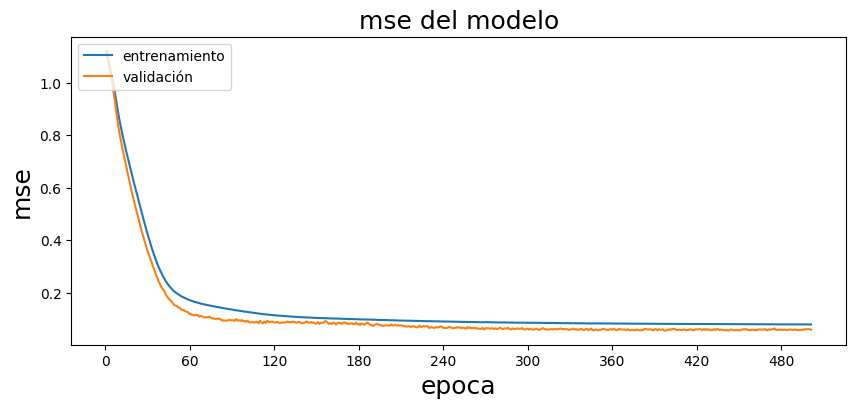


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

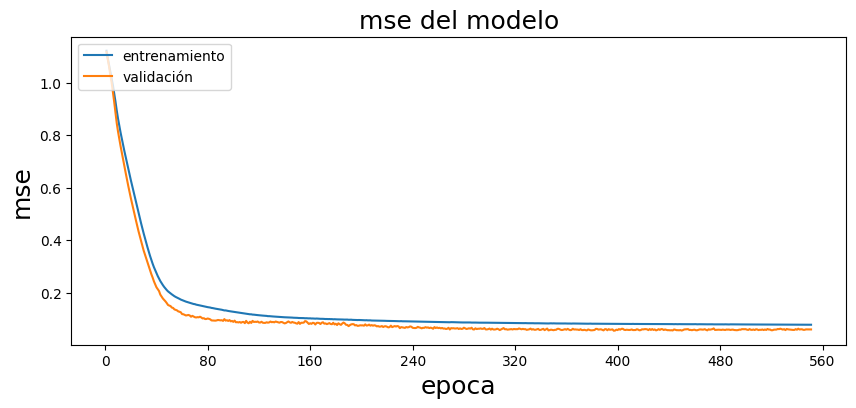


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

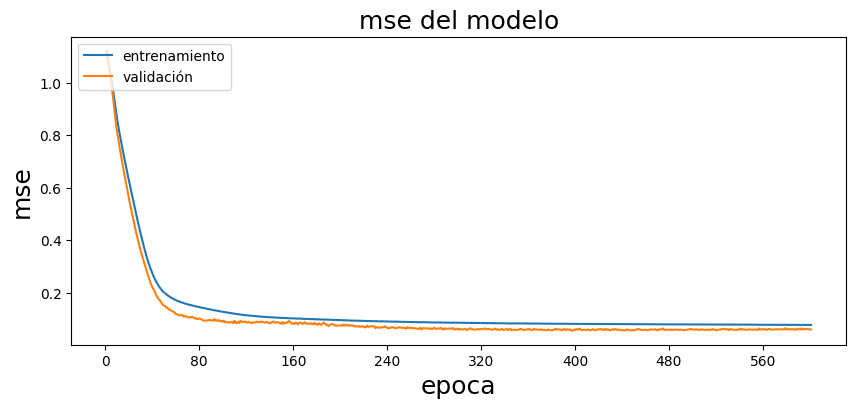


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

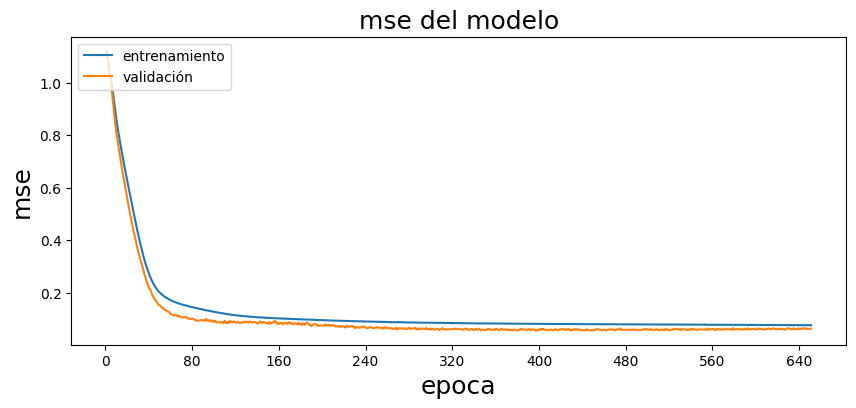


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

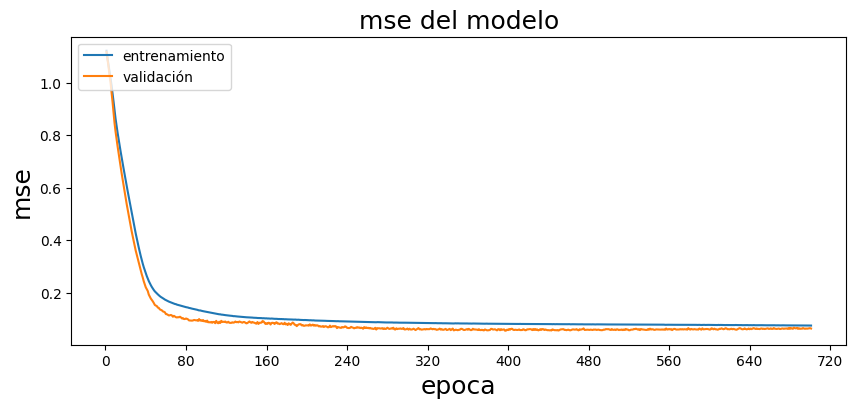


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

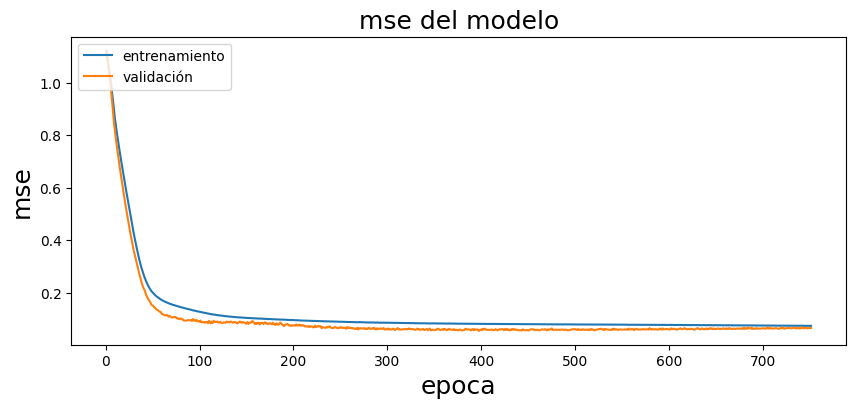


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

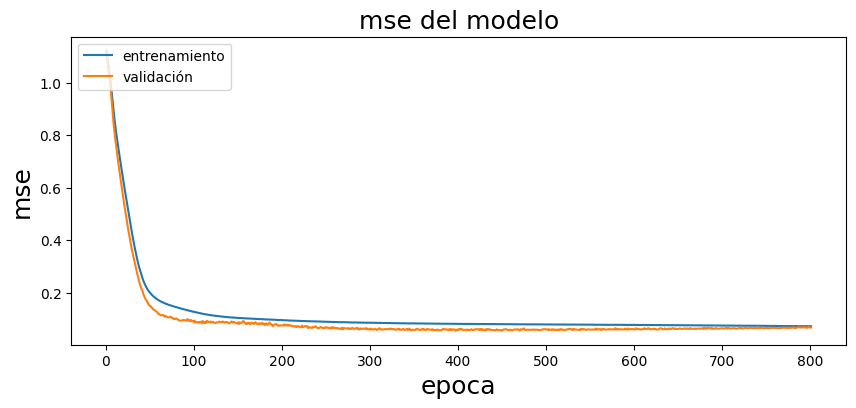


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

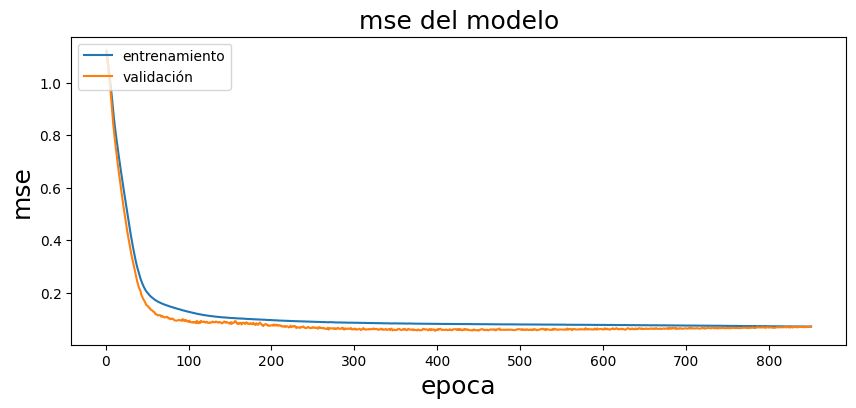


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

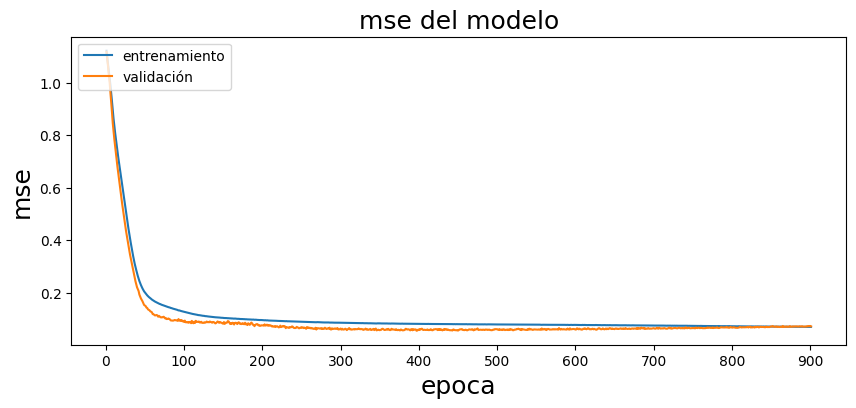


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

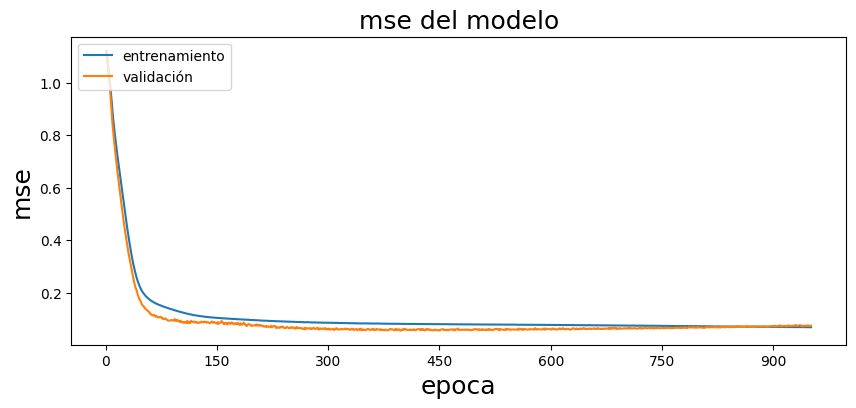


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

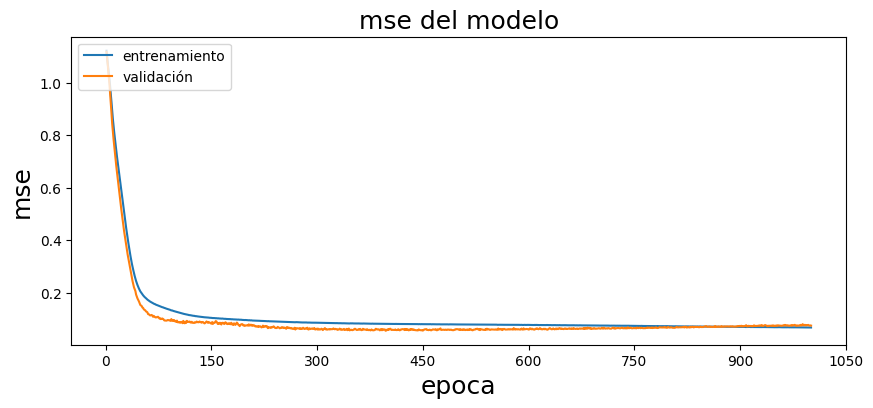


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

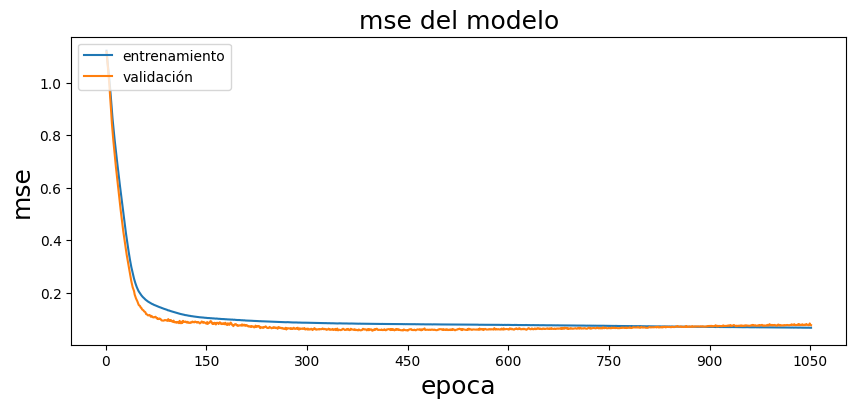


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

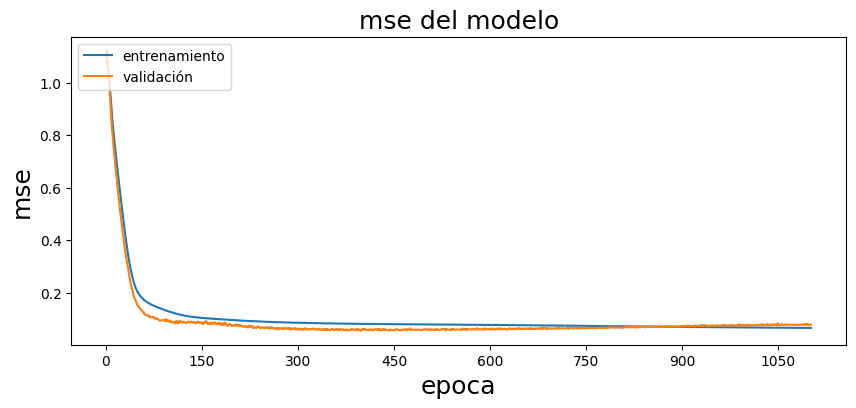


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

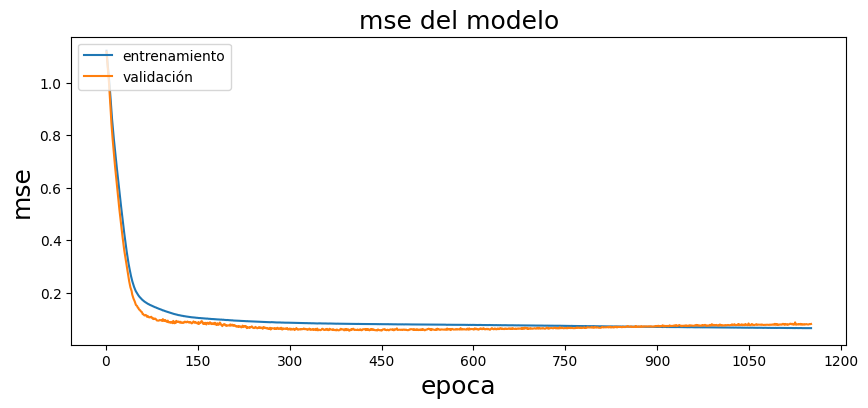


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

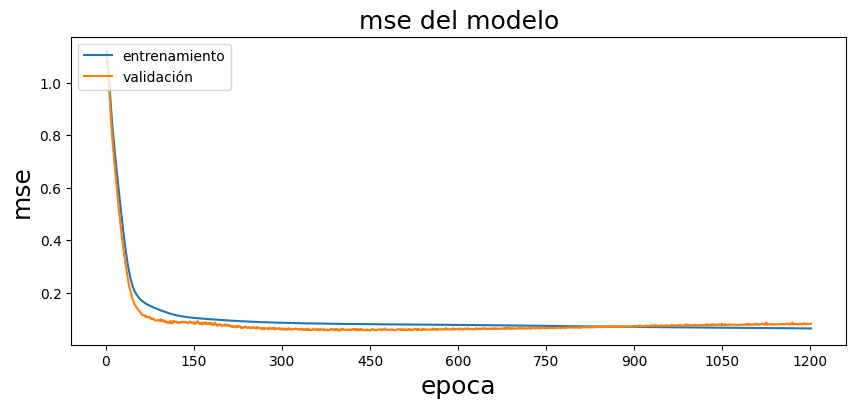


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

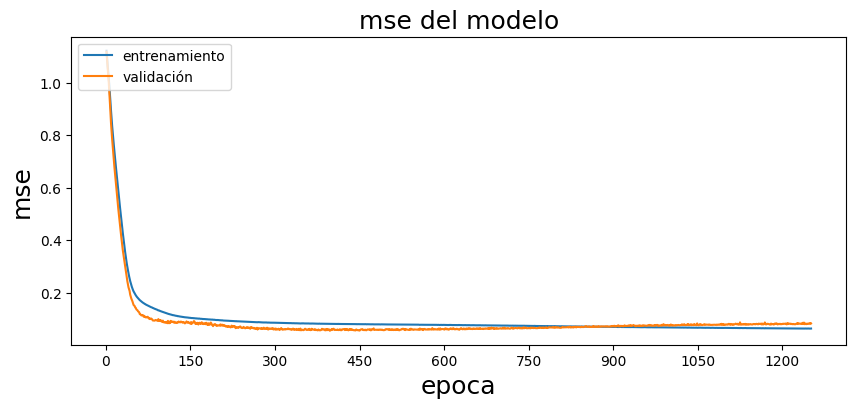


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

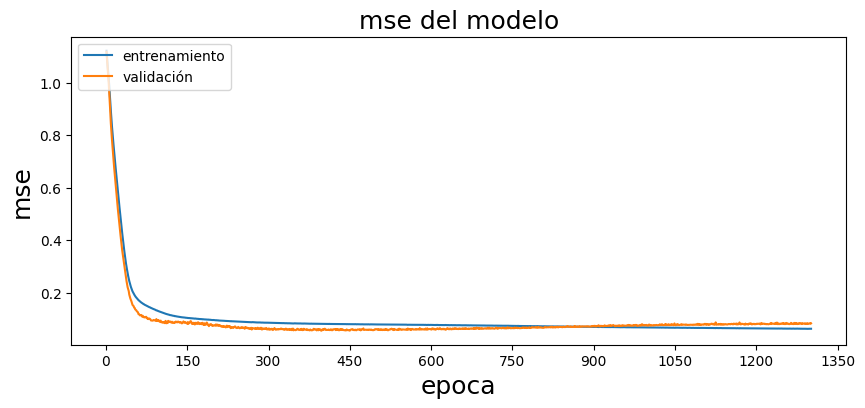


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

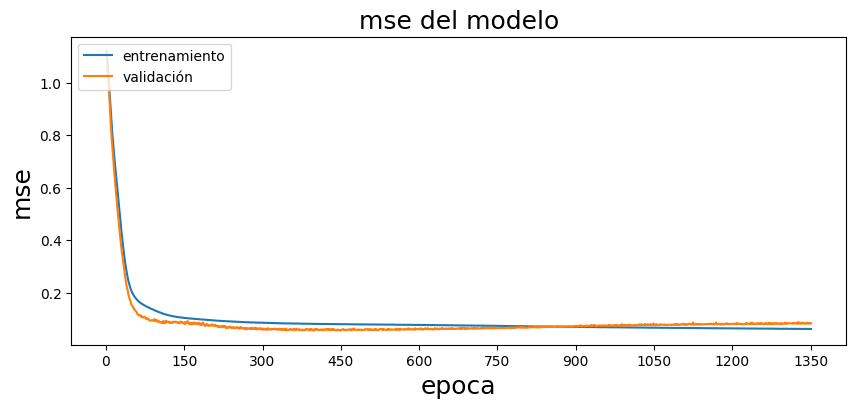


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

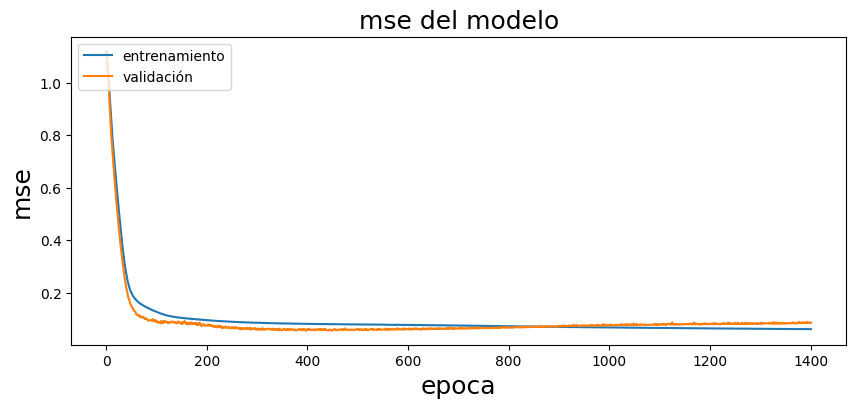


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

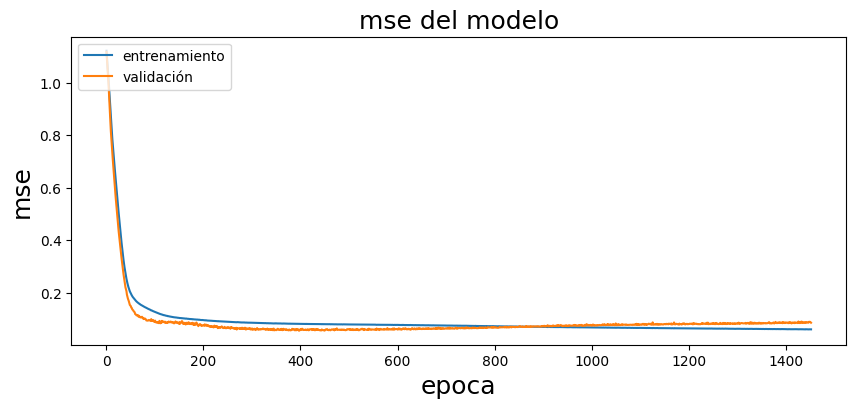


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

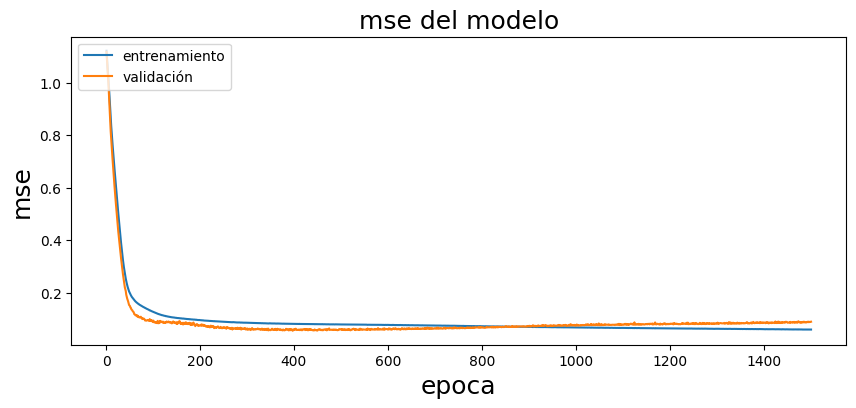


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

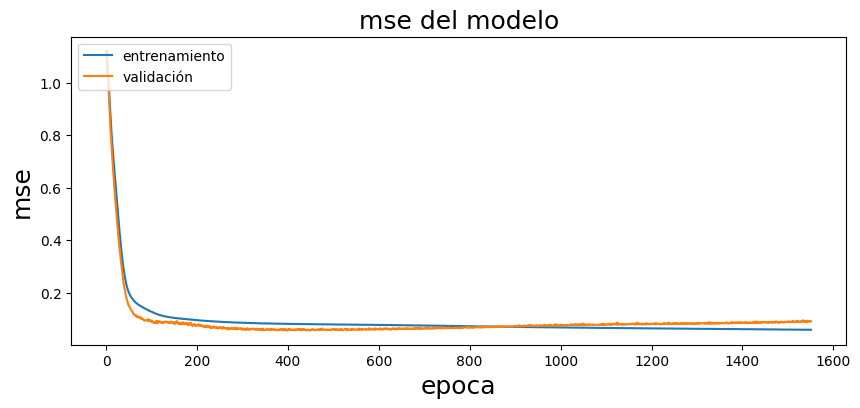


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

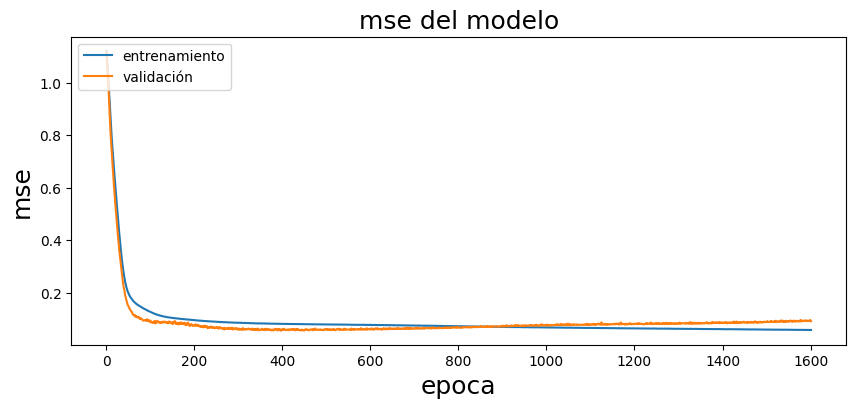


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

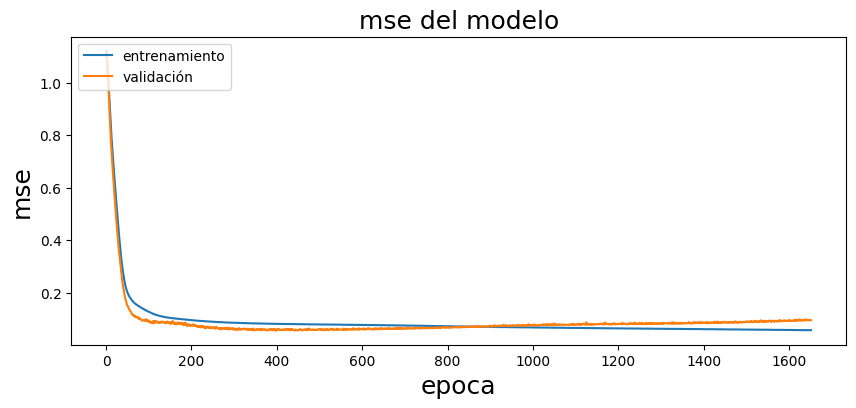


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

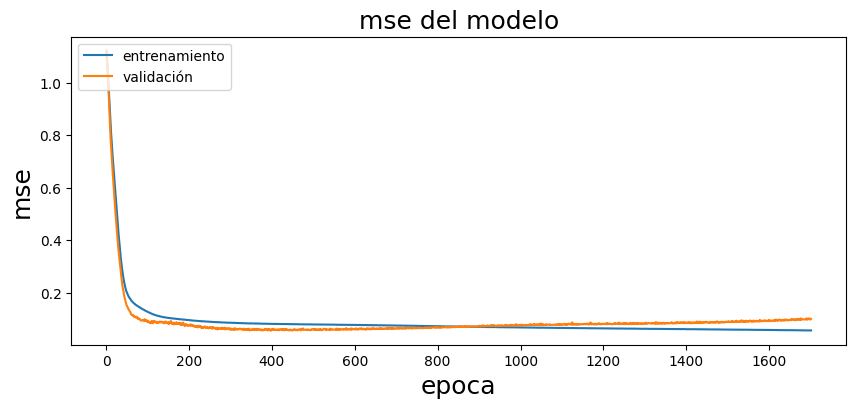


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

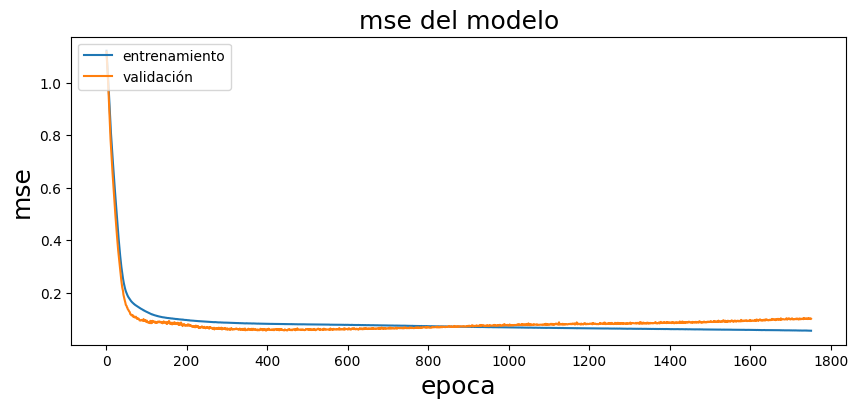


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

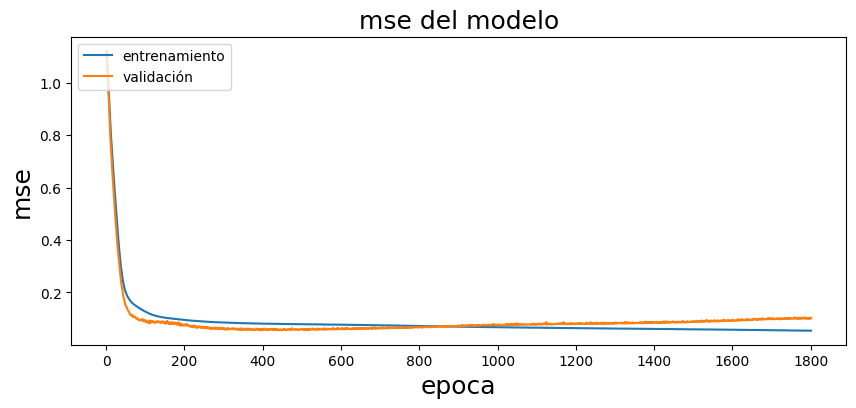


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

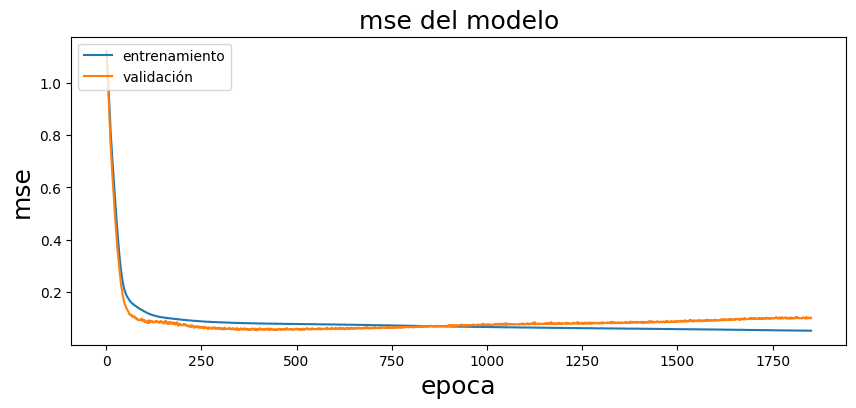


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

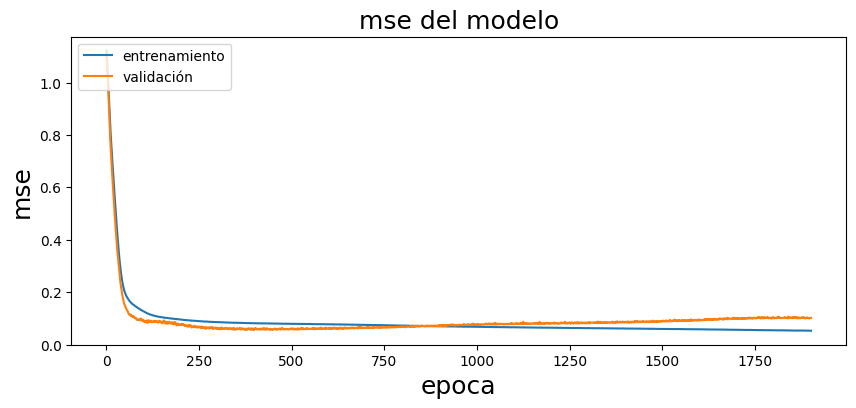


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

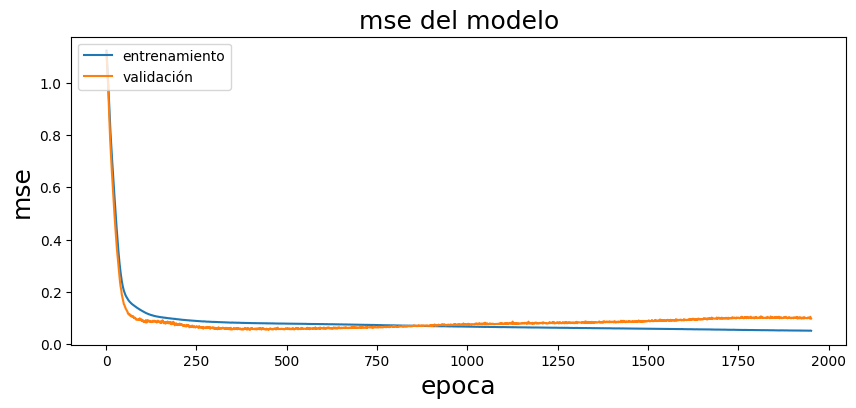


Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 0.05522

Epoch 1: val_loss did not improve from 

In [42]:
for e in range(epochs):
  history = model.fit(Xs_tr, y_tr, batch_size=batch_size, epochs=1,
                      callbacks=[checkpoint], verbose=0, validation_data=(Xs_va, y_va))
  tr_loss_history += history.history["loss"]
  va_loss_history += history.history["val_loss"]
  if e%50 == 0:
    grafica_entrenamiento(tr_loss_history, va_loss_history)

In [43]:
model = load_model(modelpath)

In [44]:
y_tr_prediction = model.predict(Xs_tr, verbose=0)

In [45]:
y_va_prediction = model.predict(Xs_va, verbose=0)

In [46]:
y_test_prediction = model.predict(Xs_test, verbose=0)

In [47]:
target_tr_pred = scaler.inverse_transform(y_tr_prediction).flatten() # des-estandarización de los pasajeros
target_va_pred = scaler.inverse_transform(y_va_prediction).flatten()
target_test_pred = scaler.inverse_transform(y_test_prediction).flatten()

In [48]:
# antes separé y_train en y_tr e y_va (estandarizados),
# pero no hice lo mismo con target_train (sin estandarizar)
# Ahora lo hago:
fechas_tr = fechas_train[:len(y_tr)]
fechas_va = fechas_train[len(y_tr):]
target_tr = target_train[:len(y_tr)]
target_va = target_train[len(y_tr):]

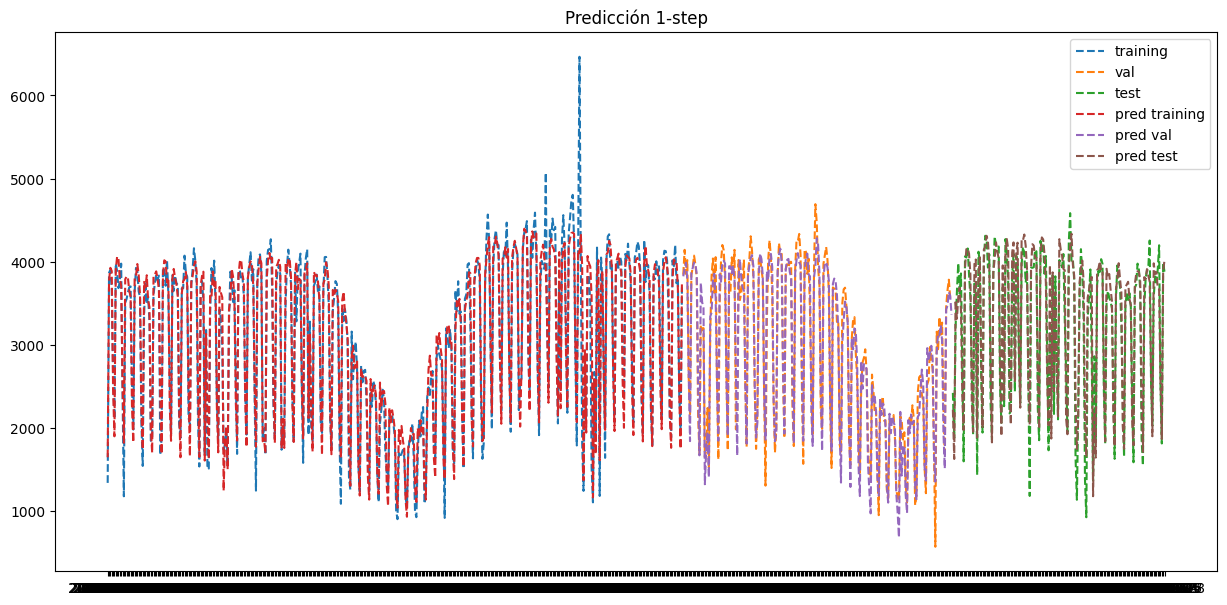

In [49]:
plt.figure(figsize=(15,7))
plt.plot(fechas_tr, target_tr, '--', label="training")
plt.plot(fechas_va, target_va, '--', label="val")
plt.plot(fechas_test, target_test, '--', label="test")
plt.plot(fechas_tr, target_tr_pred, '--', label="pred training")
plt.plot(fechas_va, target_va_pred, '--', label="pred val")
plt.plot(fechas_test, target_test_pred, '--', label="pred test")
plt.legend()
plt.title("Predicción 1-step");

In [50]:
!cal 9 2016

/bin/bash: line 1: cal: command not found


In [51]:
fechas_test[0]

'2016-09-24'

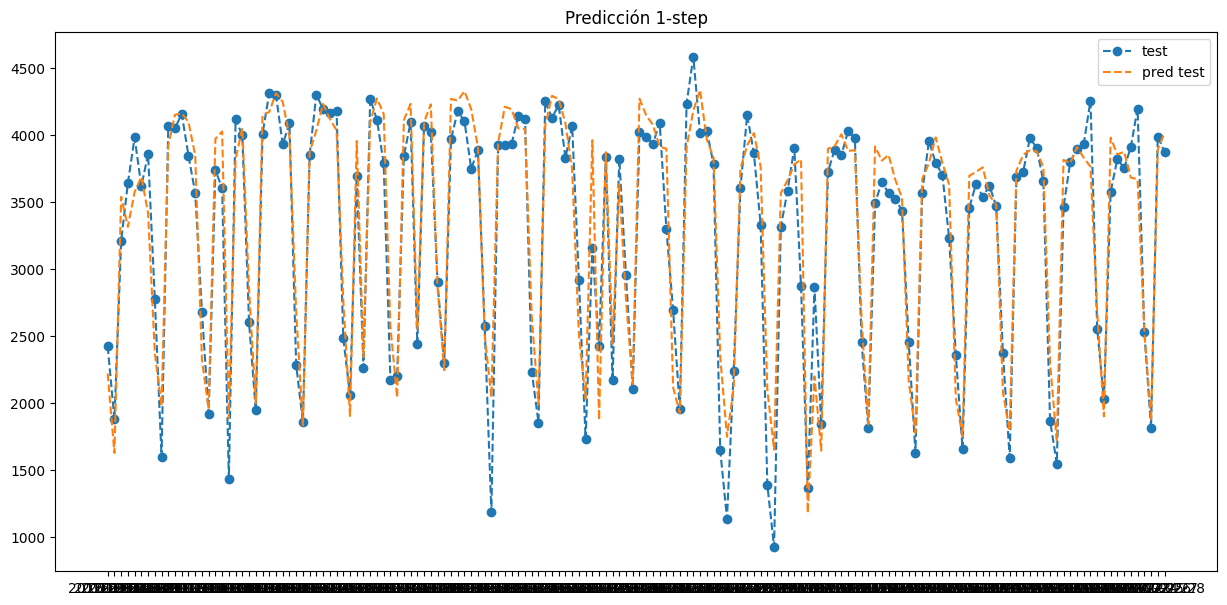

In [52]:
plt.figure(figsize=(15,7))
plt.plot(fechas_test, target_test, '--o', label="test")
plt.plot(fechas_test, target_test_pred, '--', label="pred test")
plt.legend()
plt.title("Predicción 1-step");

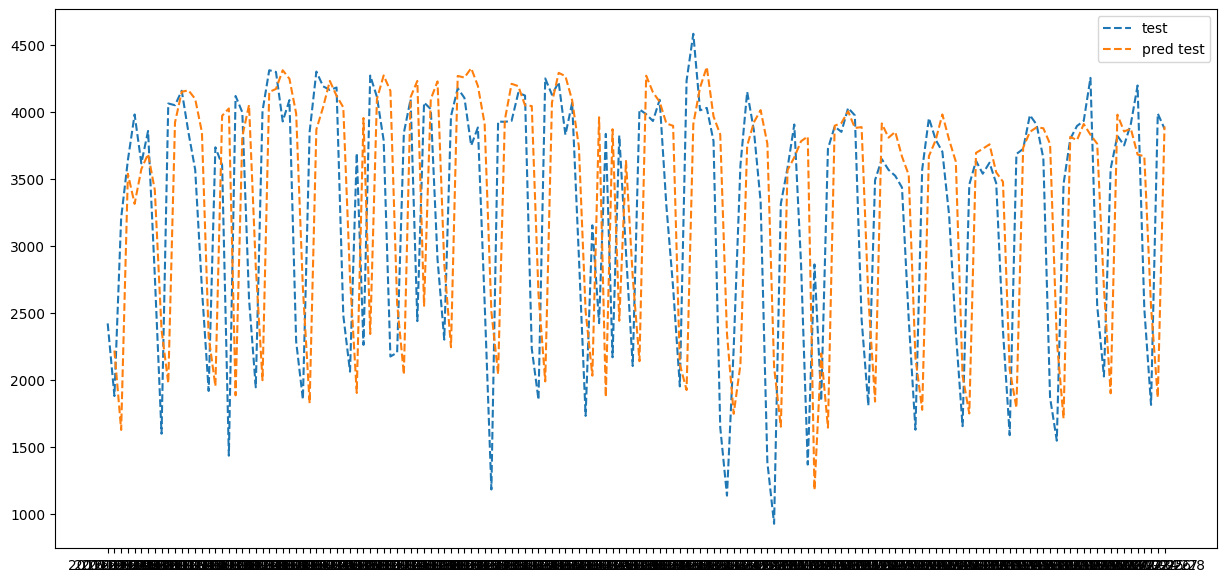

In [53]:
# esto es lo que daría si el modelo no tuviera ni idea (predice mañana lo mismo que hoy, "MODELO PERSISTENTE A 1 DÍA")

plt.figure(figsize=(15,7))
plt.plot(fechas_test, target_test, '--', label="test")
plt.plot(fechas_test[1:], target_test_pred[:-1], '--', label="pred test")
plt.legend();

In [54]:
R2_score(target_tr, target_tr_pred), R2_score(target_va, target_va_pred), R2_score(target_test, target_test_pred)

(0.9191423654556274, 0.9428830146789551, 0.8984929919242859)

In [55]:
from sklearn.metrics import mean_squared_error as MSE

MSE(target_tr, target_tr_pred), MSE(target_va, target_va_pred), MSE(target_test, target_test_pred)

(83165.1328125, 56345.73046875, 83818.125)

In [56]:
1 - MSE(target_tr, target_tr_pred) / target_tr.var()

np.float64(0.9191423645920521)

R2 en test de modelo persistente a 1 días: -0.43938350677490234
R2 en test de modelo persistente a 2 días: -1.4071376323699951
R2 en test de modelo persistente a 3 días: -1.5919959545135498
R2 en test de modelo persistente a 4 días: -1.5399794578552246
R2 en test de modelo persistente a 5 días: -1.4761505126953125
R2 en test de modelo persistente a 6 días: -0.6319113969802856
R2 en test de modelo persistente a 7 días: 0.431027889251709
R2 en test de modelo persistente a 8 días: -0.39640700817108154
R2 en test de modelo persistente a 9 días: -1.4767720699310303
R2 en test de modelo persistente a 10 días: -1.5359525680541992
R2 en test de modelo persistente a 11 días: -1.5017101764678955
R2 en test de modelo persistente a 12 días: -1.521932601928711
R2 en test de modelo persistente a 13 días: -0.6627095937728882
R2 en test de modelo persistente a 14 días: 0.40248537063598633
R2 en test de modelo persistente a 15 días: -0.47928357124328613
R2 en test de modelo persistente a 16 días: -1.46

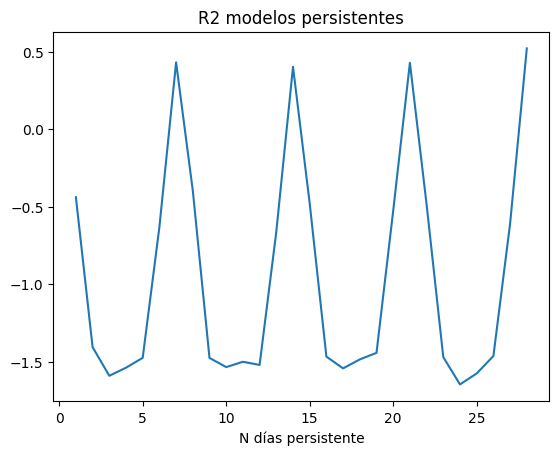

In [57]:
# Extraigo métricas de diferentes modelos persistentes a N días:

R2_persistentes = []
rango = range(1, 4*7+1)
for i in rango:
  score = R2_score(target_test[i:], target_test_pred[:-i])
  R2_persistentes.append(score)
  print("R2 en test de modelo persistente a {} días: {}".format(i, score))

plt.plot(rango, R2_persistentes)
plt.title("R2 modelos persistentes")
plt.xlabel("N días persistente");

In [58]:
embeddings_mes = model.get_layer("embedding_mes").get_weights()[0]
embeddings_mes.shape

(12, 2)

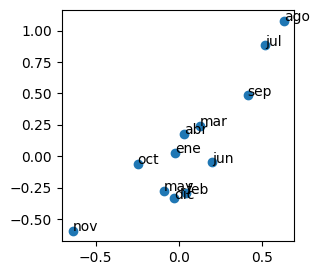

In [59]:
plt.figure(figsize=(3,3))
plt.plot(embeddings_mes[:,0], embeddings_mes[:,1], "o")
nombres = ["ene","feb","mar","abr","may","jun","jul","ago","sep","oct","nov","dic"]
for coords,nombre in zip(embeddings_mes,nombres):
  plt.text(coords[0],coords[1],nombre)

In [60]:
embeddings_day_of_week = model.get_layer("embedding_day_of_week").get_weights()[0]
embeddings_day_of_week.shape

(7, 2)

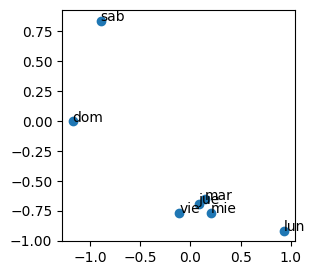

In [61]:
plt.figure(figsize=(3,3))
plt.plot(embeddings_day_of_week[:,0], embeddings_day_of_week[:,1], "o")
nombres = ["lun","mar","mie","jue","vie","sab","dom"]
for coords,nombre in zip(embeddings_day_of_week,nombres):
  plt.text(coords[0],coords[1],nombre)

In [62]:
embeddings_semana_mes = model.get_layer("embedding_semana_mes").get_weights()[0]
embeddings_semana_mes.shape

(3, 2)

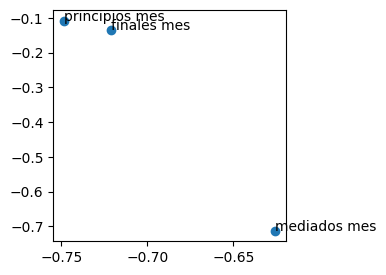

In [63]:
plt.figure(figsize=(3,3))
plt.plot(embeddings_semana_mes[:,0], embeddings_semana_mes[:,1], "o")
nombres = ["principios mes","mediados mes","finales mes"]
for coords,nombre in zip(embeddings_semana_mes,nombres):
  plt.text(coords[0],coords[1],nombre)

In [64]:
def multistep(model, Xs): # el número de ventanas en Xs = número de días hacia delante que quiero predecir
  ventana_endogena = Xs["endogena"][:1].copy()
  salidas = []
  for i in range(len(Xs["festivo"])):
    z = model.predict( # predigo un solo día (día i)
        {
            "endogena": ventana_endogena,
            "festivo": Xs["festivo"][i:(i+1)],
            "mes": Xs["mes"][i:(i+1)],
            "semana_mes": Xs["semana_mes"][i:(i+1)],
            "day_of_week": Xs["day_of_week"][i:(i+1)]
        }, verbose=0
    )
    ventana_endogena[:-1] = ventana_endogena[1:] # desplazo un día la ventana
    ventana_endogena[-1]  = z[0][0] # predicción
    salidas.append(scaler.inverse_transform(z)[0,0])

  return salidas

In [65]:
Xs_test["endogena"][0]

array([[0.43465537],
       [0.63462819],
       [0.76332356],
       [0.54751132],
       [0.57721025]])

In [66]:
Xs_test["endogena"][1]

array([[ 0.63462819],
       [ 0.76332356],
       [ 0.54751132],
       [ 0.57721025],
       [-0.58401802]])

In [67]:
Xs_test["endogena"][0].shape

(5, 1)

In [68]:
sal = multistep(model, Xs_test)

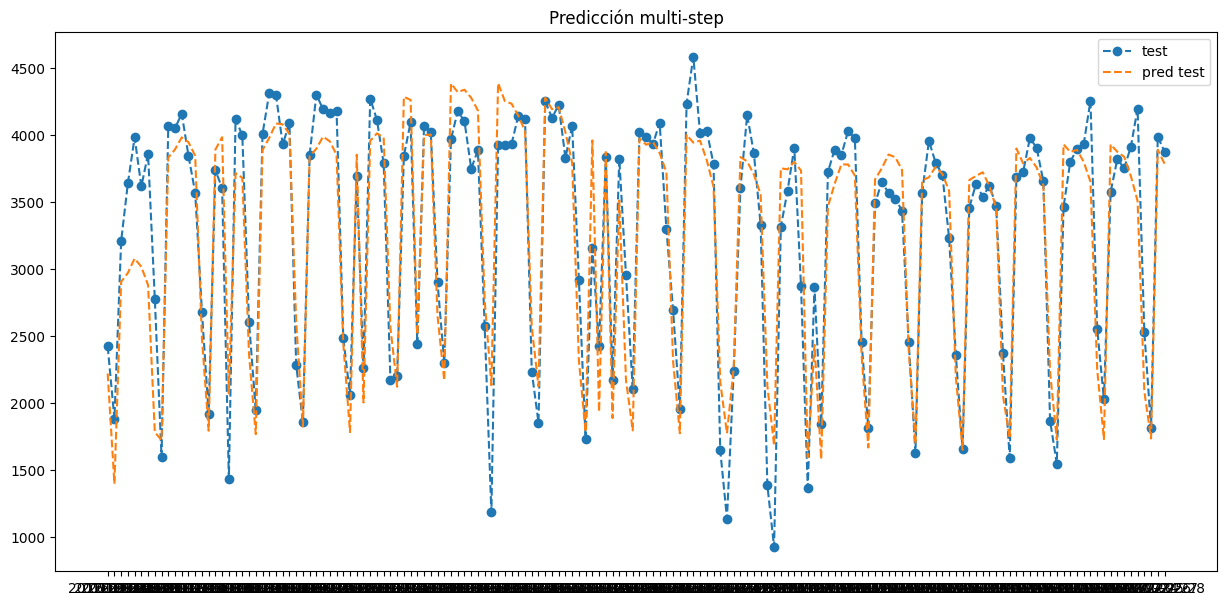

In [69]:
plt.figure(figsize=(15,7))
plt.plot(fechas_test, target_test, '--o', label="test")
plt.plot(fechas_test, sal, '--', label="pred test")
plt.legend()
plt.title("Predicción multi-step");

In [70]:
R2_score(target_test[:14], sal[:14])

0.5484419016283801

In [71]:
import pickle
aux = {
    "estandarizador": scaler,
    "data_window": data_window
}
with open("datos_modelo.pkl", "wb") as f:
  pickle.dump(aux, f)

## Producción

In [72]:
model = load_model(modelpath)

In [73]:
import pickle
with open("datos_modelo.pkl", "rb") as f:
  aux = pickle.load(f)
aux

{'estandarizador': StandardScaler(), 'data_window': 5}

In [74]:
scaler = aux["estandarizador"]
data_window = aux["data_window"]

In [75]:
data2 = data[-30:].copy()
data2["npasajeros"][5:] = NAN
data2

/tmp/ipykernel_8991/3313719011.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data2["npasajeros"][5:] = NAN


,mes,festivo,npasajeros,semana_mes,day_of_week
fecha,,,,,
2017-01-30,1,0,3460.0,2,0
2017-01-31,1,0,3637.0,2,1
2017-02-01,2,0,3541.0,0,2
2017-02-02,2,0,3623.0,0,3
2017-02-03,2,0,3469.0,0,4
2017-02-04,2,0,NaN,0,5
2017-02-05,2,0,NaN,0,6
2017-02-06,2,0,NaN,0,0
2017-02-07,2,0,NaN,0,1


In [76]:
fechas      = data2.index.values
target      = data2["npasajeros"].values
festivo     = data2["festivo"].values
mes         = data2["mes"].values
semana_mes  = data2["semana_mes"].values
day_of_week = data2["day_of_week"].values
target_transf = scaler.transform(data2[["npasajeros"]]).flatten()

mes = mes - 1

In [77]:
target_transf[:10]

array([0.44158513, 0.61680883, 0.52177224, 0.60294933, 0.45049481,
              nan,        nan,        nan,        nan,        nan])

In [78]:
# Lo anterior era una prueba. Ahora voy a enventanar cada
# variable por separado, porque las voy a tratar por separado
# en mi red

series0         = [target_transf]
se_saben_antes0 = [False]
nombres_series0 = ["target_transf"]

X0, y = enventanar(series0,
                  target=0, # cuál es la variable endógena a predecir
                  se_saben_antes=se_saben_antes0,
                  W_in=data_window)


series1         = [festivo]
se_saben_antes1 = [True]
nombres_series1 = ["festivo"]

X1, _ = enventanar(series1,
                  target=0, # cuál es la variable endógena a predecir
                  se_saben_antes=se_saben_antes1,
                  W_in=data_window)

series2         = [mes]
se_saben_antes2 = [True]
nombres_series2 = ["mes"]

X2, _ = enventanar(series2,
                  target=0, # cuál es la variable endógena a predecir
                  se_saben_antes=se_saben_antes2,
                  W_in=data_window)

series3         = [semana_mes]
se_saben_antes3 = [True]
nombres_series3 = ["semana_mes"]

X3, _ = enventanar(series3,
                  target=0, # cuál es la variable endógena a predecir
                  se_saben_antes=se_saben_antes3,
                  W_in=data_window)

series4         = [day_of_week]
se_saben_antes4 = [True]
nombres_series4 = ["day_of_week"]

X4, _ = enventanar(series4,
                  target=0, # cuál es la variable endógena a predecir
                  se_saben_antes=se_saben_antes4,
                  W_in=data_window)

In [79]:
Xs_prod = {
    "endogena": X0[data_window:],
    "festivo": X1[data_window:],
    "mes": X2[data_window:],
    "semana_mes": X3[data_window:],
    "day_of_week": X4[data_window:],
}

In [80]:
sal = multistep(model, Xs_prod)

In [81]:
sal

[np.float32(2080.1897),
 np.float32(1738.1011),
 np.float32(3900.6365),
 np.float32(3789.7288),
 np.float32(3830.0479),
 np.float32(3760.2197),
 np.float32(3625.8965),
 np.float32(2232.5989),
 np.float32(1729.7614),
 np.float32(3931.6914),
 np.float32(3875.3394),
 np.float32(3890.4917),
 np.float32(3800.7097),
 np.float32(3652.7852),
 np.float32(2250.7905),
 np.float32(1732.37),
 np.float32(3931.5525),
 np.float32(3875.2588),
 np.float32(3839.0347),
 np.float32(3695.6436),
 np.float32(3508.8706),
 np.float32(2089.6445),
 np.float32(1736.7513),
 np.float32(3891.387),
 np.float32(3787.5764)]

In [82]:
data2["prediccion"] = NAN
data2["prediccion"].iloc[data_window:] = sal

/tmp/ipykernel_8991/3856504132.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data2["prediccion"].iloc[data_window:] = sal
/tmp/ipykernel_8991/3856504132.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fr

In [83]:
data2

,mes,festivo,npasajeros,semana_mes,day_of_week,prediccion
fecha,,,,,,
2017-01-30,1,0,3460.0,2,0,NaN
2017-01-31,1,0,3637.0,2,1,NaN
2017-02-01,2,0,3541.0,0,2,NaN
2017-02-02,2,0,3623.0,0,3,NaN
2017-02-03,2,0,3469.0,0,4,NaN
2017-02-04,2,0,NaN,0,5,2080.189697
2017-02-05,2,0,NaN,0,6,1738.101074
2017-02-06,2,0,NaN,0,0,3900.636475
2017-02-07,2,0,NaN,0,1,3789.728760


In [84]:
data2["reales"] = data["npasajeros"][-30:].copy()
data2

,mes,festivo,npasajeros,semana_mes,day_of_week,prediccion,reales
fecha,,,,,,,
2017-01-30,1,0,3460.0,2,0,NaN,3460
2017-01-31,1,0,3637.0,2,1,NaN,3637
2017-02-01,2,0,3541.0,0,2,NaN,3541
2017-02-02,2,0,3623.0,0,3,NaN,3623
2017-02-03,2,0,3469.0,0,4,NaN,3469
2017-02-04,2,0,NaN,0,5,2080.189697,2373
2017-02-05,2,0,NaN,0,6,1738.101074,1590
2017-02-06,2,0,NaN,0,0,3900.636475,3688
2017-02-07,2,0,NaN,0,1,3789.728760,3726


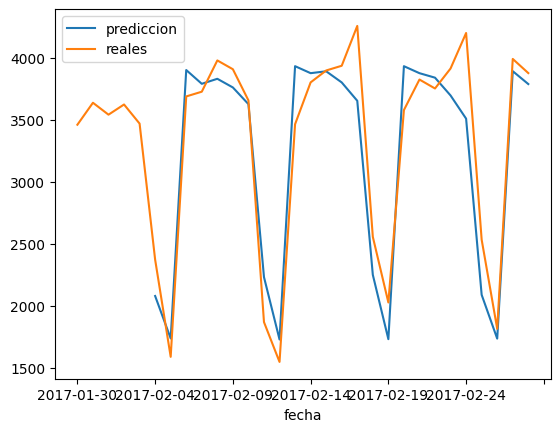

In [85]:
data2[["prediccion", "reales"]].plot();